<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Advanced-DL/blob/main/Uncertainty_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/work/teaching/2025 Advanced Deep Learning/')

In [3]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = "."

In [4]:
from huggingface_hub import hf_hub_download

hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset")
hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


'/root/.cache/huggingface/hub/datasets--simbaswe--galah4/snapshots/b1635aac832110fd159818fc5216b54f64f64672/labels.npy'

In [5]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
import helper

In [6]:
from huggingface_hub import hf_hub_download

spectra_path = hf_hub_download(
    repo_id="simbaswe/galah4",
    filename="spectra.npy",
    repo_type="dataset"
)

labels_path = hf_hub_download(
    repo_id="simbaswe/galah4",
    filename="labels.npy",
    repo_type="dataset"
)

spectra = np.load(spectra_path)
labels = np.load(labels_path)
print(spectra.shape)
print(labels.shape)
labels = labels[:, -4:-1]   # t_eff, log_g, fe_h
print(labels.shape)
labels_mean = labels.mean(axis=0)
labels_std = labels.std(axis=0)

labels = (labels - labels_mean) / labels_std

(8914, 16384)
(8914, 8)
(8914, 3)


In [7]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

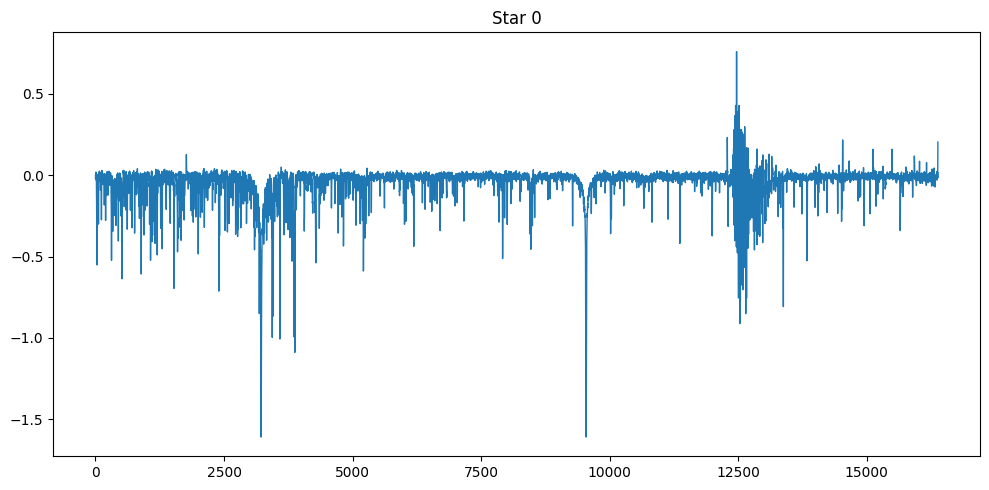

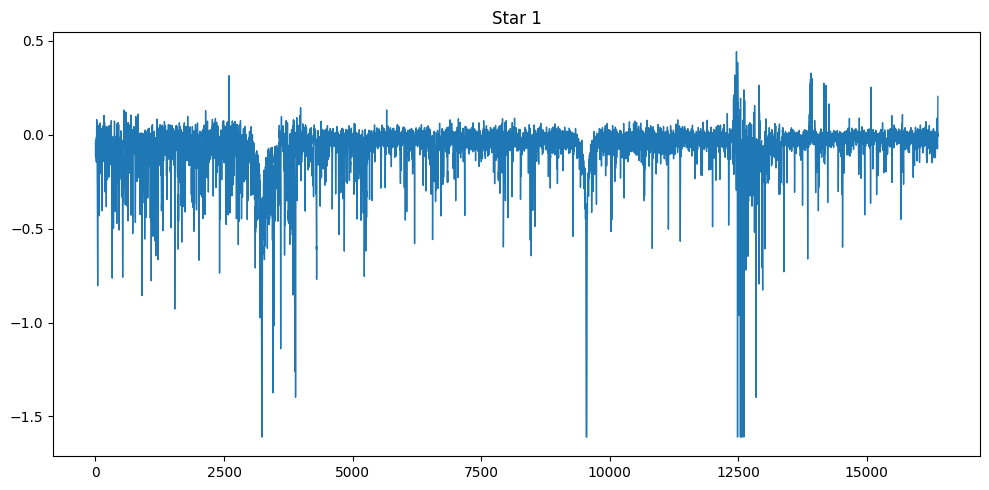

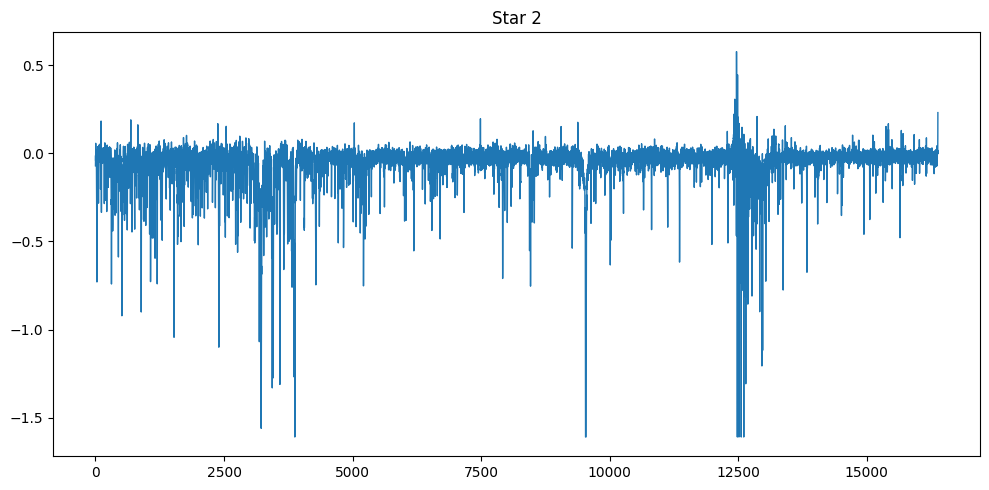

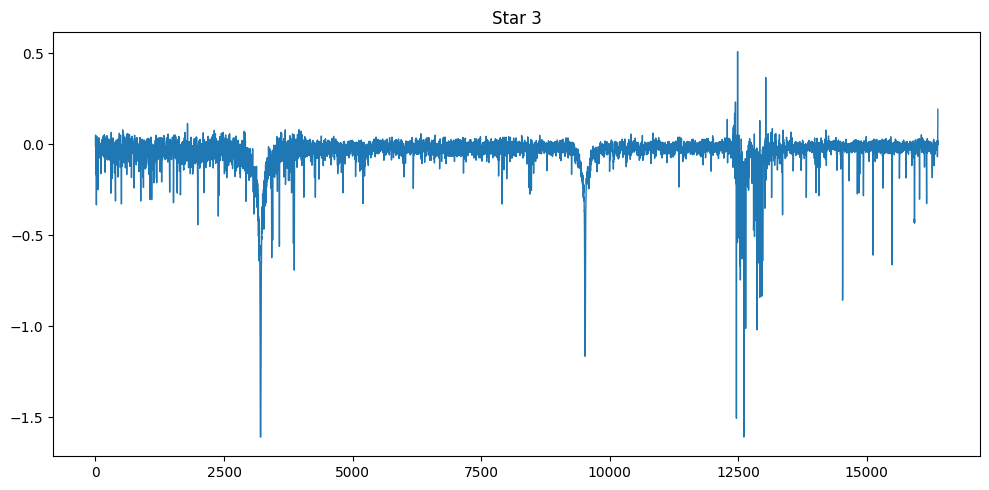

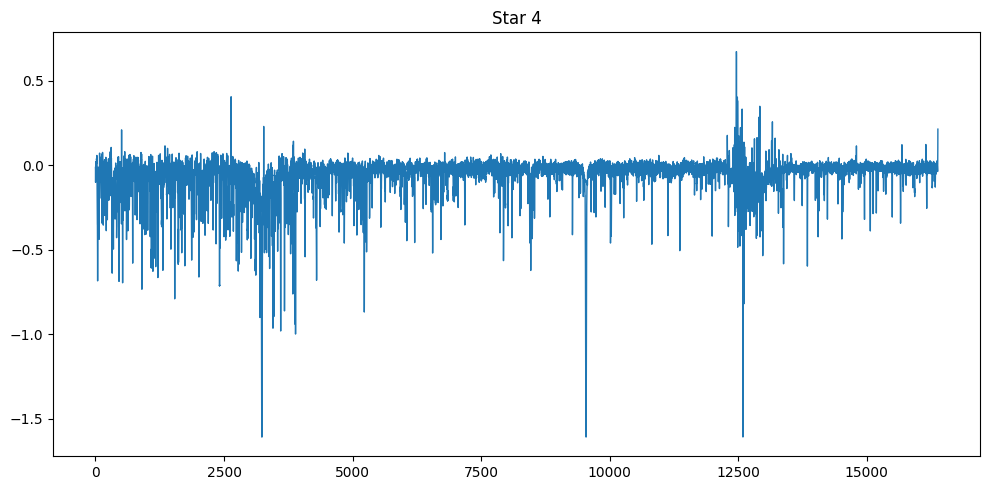

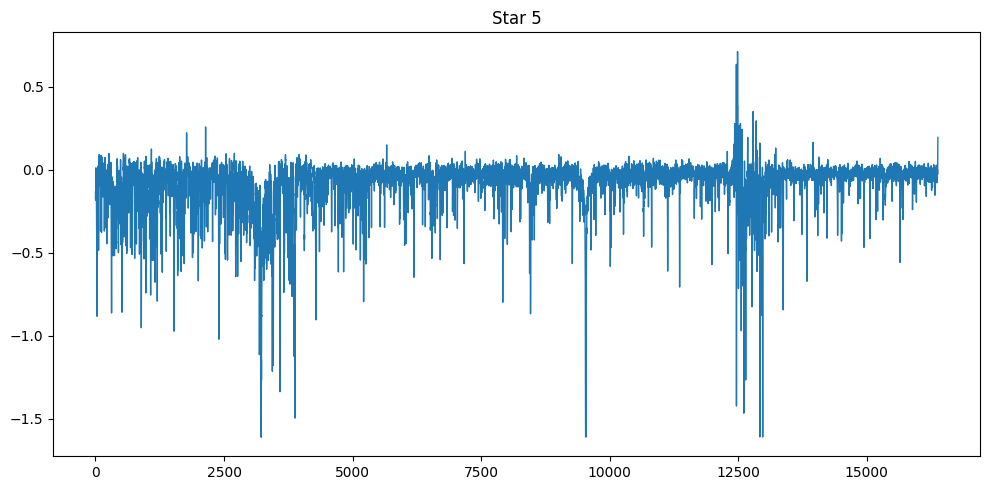

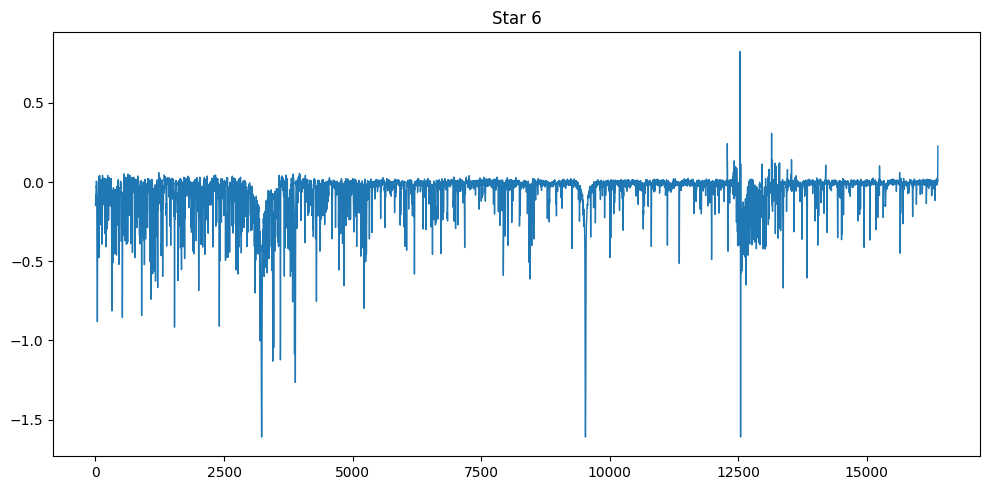

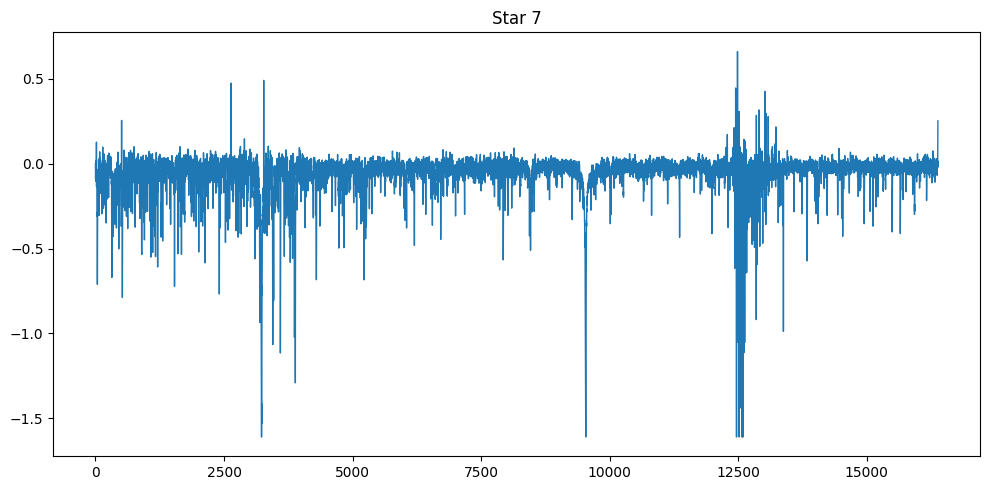

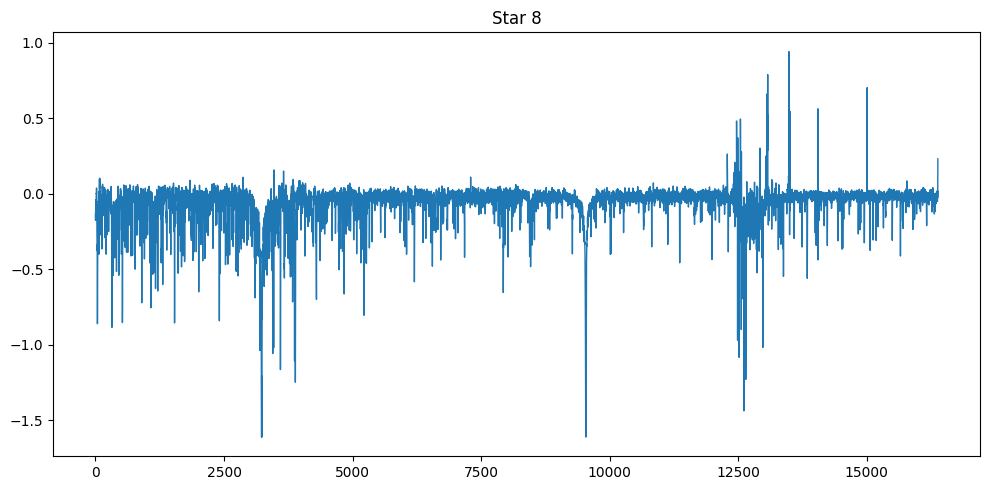

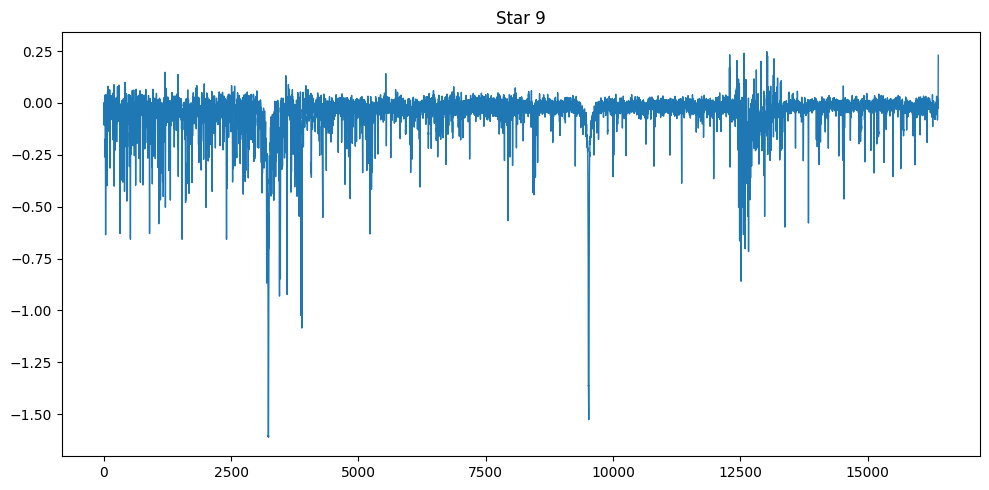

In [8]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()

In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

X = torch.tensor(spectra, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32)

X = X.unsqueeze(1)  # (N, 1, 16384)

dataset = TensorDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [22]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.flatten = nn.Flatten()

        # automatic size detection trick 🔥
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16384)
            dummy_out = self.conv(dummy)
            n_features = dummy_out.shape[1] * dummy_out.shape[2]

        self.fc = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 6)
        )

    def forward(self, x):
      x = self.conv(x)
      x = self.flatten(x)
      x = self.fc(x)

      mu = x[:, :3]
      log_sigma = x[:, 3:]

      return mu, log_sigma

model = CNNModel()

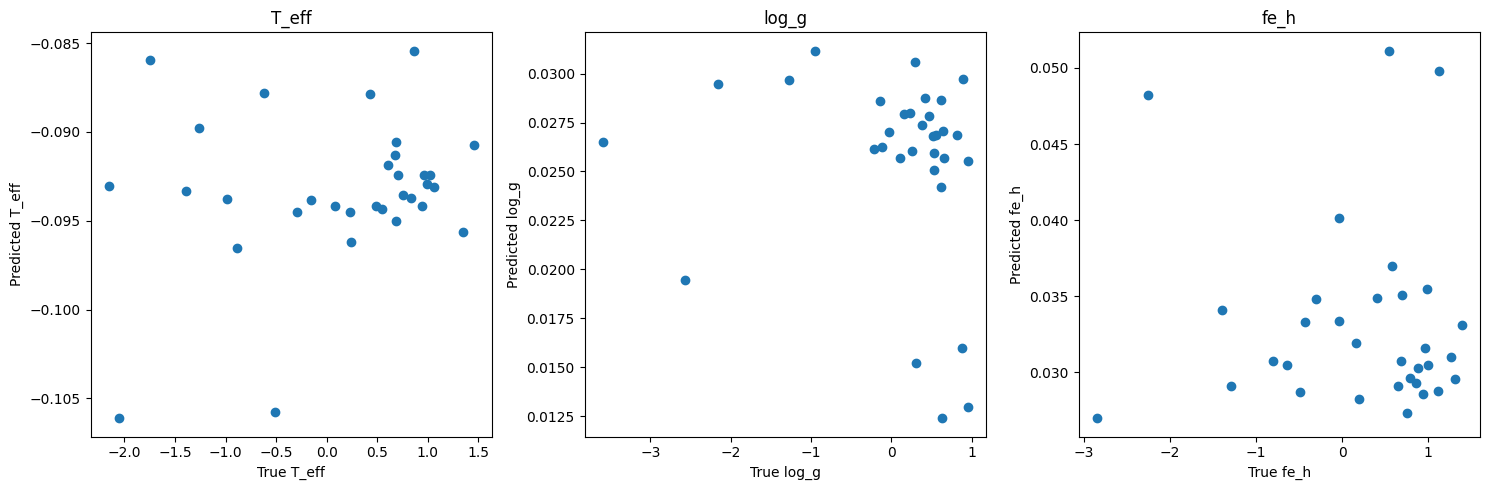

In [33]:
# Uncertainty Prediction using Neural Networks


# This model predicts:
# - Mean (mu) → actual prediction
# - Log standard deviation (log_sigma) → uncertainty
# We use Gaussian Negative Log-Likelihood (NLL) loss

import torch
import matplotlib.pyplot as plt


# Loss Function (NLL)

def nll_loss(y_true, mu, log_sigma):
    # Convert log_sigma → sigma (ensures positivity)
    sigma = torch.exp(log_sigma)

    # Gaussian NLL loss:
    # (y - mu)^2 / (2*sigma^2) + log(sigma)
    loss = ((y_true - mu)**2) / (2 * sigma**2) + log_sigma

    return loss.mean()



# Evaluation

model.eval()

# Get a batch from validation data
xb, yb = next(iter(val_loader))

# Model outputs:
# mu → predictions
# log_sigma → uncertainty (in log form)
mu, log_sigma = model(xb)

# Convert to numpy for plotting
preds = mu.detach().cpu().numpy()
sigma = torch.exp(log_sigma).detach().cpu().numpy()
yb = yb.cpu().numpy()


# Plot: Predictions vs True values

# If model is good → points should lie near diagonal
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(["T_eff", "log_g", "fe_h"]):
    axes[i].scatter(yb[:, i], preds[:, i])
    axes[i].set_xlabel(f"True {name}")
    axes[i].set_ylabel(f"Predicted {name}")
    axes[i].set_title(name)

plt.tight_layout()
plt.show()




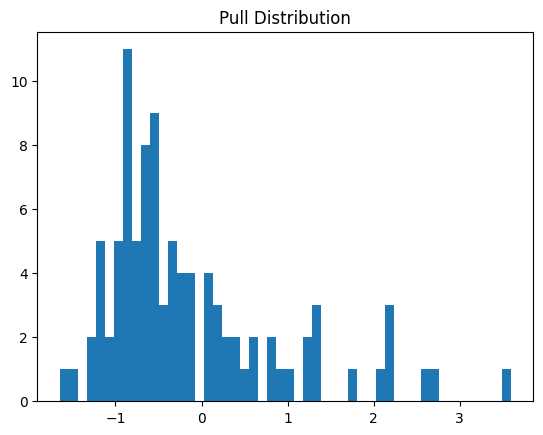

Mean: -0.13385905
Std: 1.0200465


In [34]:
# Pull Distribution
# pull = (prediction - true) / uncertainty
# Used to check if uncertainty is correct

pull = (preds - yb) / sigma

# Plot histogram
plt.hist(pull.flatten(), bins=50)
plt.title("Pull Distribution")
plt.show()

# Print statistics
mean_pull = pull.mean()
std_pull = pull.std()

print("Mean:", mean_pull)
print("Std:", std_pull)

# Interpretation

# If:
# Mean ≈ 0 → predictions are unbiased
# Std ≈ 1 → uncertainty is well-calibrated

# Your result:
# Mean ≈ -0.13 → slight bias (acceptable)
# Std ≈ 1.02 → very close to 1 → GOOD calibration

# Conclusion:
# The model predicts reliable uncertainties with minor bias.